## Maze Solver - Solution Validation Analysis

## Automatically discovers all trained models in models/NxN/ and runs
## validation analysis for each one. Generates datasets on the fly,
## evaluates exact match vs valid solution rate, and saves results.

In [15]:
import os
import sys
import re
import json
import torch
import subprocess
import numpy as np
from datetime import datetime
from PIL import Image
from torch.utils.data import DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt

sys.path.insert(0, 'src')

from config import get_config
from model import ResNetGPT2PrefixModel
from tokenizer import SimpleTokenizer
from dataset import MazeDataset, collate_fn
from solution_validator import validate_solution, evaluate_with_validation, print_evaluation_results
from data_utils import load_maze_dataset, print_dataset_info

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
tokenizer = SimpleTokenizer()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print(f"Device: {device}")

Device: cpu


## Discover Models

In [16]:
# Scan models/ directory for all NxN checkpoints
model_dirs = sorted([
    d for d in os.listdir('models')
    if os.path.isdir(f'models/{d}') and re.match(r'\d+x\d+', d)
])

print(f"Found {len(model_dirs)} model(s):")
for d in model_dirs:
    pth = f'models/{d}/resnet_gpt2_prefix.pth'
    size = os.path.getsize(pth) / 1e6 if os.path.exists(pth) else 0
    print(f"  models/{d}/resnet_gpt2_prefix.pth  ({size:.1f} MB)")

Found 2 model(s):
  models/4x4/resnet_gpt2_prefix.pth  (49.0 MB)
  models/5x5/resnet_gpt2_prefix.pth  (49.0 MB)


## Helper Functions

In [17]:
def load_maze_grid(image_path, grid_rows, grid_cols):
    """Convert maze image to binary grid (0=path, 1=wall)."""
    img_rgb = Image.open(image_path).convert('RGB')
    img_array_rgb = np.array(img_rgb)
    img_gray = Image.open(image_path).convert('L')
    img_array_gray = np.array(img_gray)

    height, width = img_array_gray.shape
    cell_height = height // grid_rows
    cell_width = width // grid_cols

    grid = np.zeros((grid_rows, grid_cols), dtype=int)

    for row in range(grid_rows):
        for col in range(grid_cols):
            center_y = row * cell_height + cell_height // 2
            center_x = col * cell_width + cell_width // 2
            r, g, b = img_array_rgb[center_y, center_x]

            is_green = (g > 100 and g > r and g > b)
            is_blue = (b > 100 and b > r and b > g)

            if is_green or is_blue:
                grid[row, col] = 0
            else:
                pixel_value = img_array_gray[center_y, center_x]
                grid[row, col] = 1 if pixel_value < 127 else 0

    return grid


def analyze_one_model(grid_size, checkpoint_path):
    """
    Generate dataset, load model, evaluate, and return results dict.
    """
    cfg = get_config(grid_size)
    variations = {4: 150, 5: 100, 7: 50}.get(grid_size, 50)

    # Generate the dataset for this grid size
    print(f"\n{'='*70}")
    print(f"  ANALYZING {grid_size}x{grid_size}")
    print(f"{'='*70}")

    subprocess.run(
        [sys.executable, 'generate_dataset.py', '--size', str(grid_size),
         '--variations', str(variations), '--seed', '69'],
        check=True, capture_output=True
    )
    print(f"Generated {grid_size}x{grid_size} dataset")

    # Load test data from NxN directory
    data_dir = f'data/{grid_size}x{grid_size}'
    test_entries, metadata = load_maze_dataset(f'{data_dir}/test_sequences.json')
    print_dataset_info(metadata, len(test_entries), dataset_name="Test")

    # Build maze grids for validation
    maze_grids = {}
    for entry in test_entries:
        maze_grids[entry['id']] = load_maze_grid(
            entry['image'], grid_rows=grid_size, grid_cols=grid_size
        )
    print(f"Loaded {len(maze_grids)} maze grids")

    # Load model
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    total_params = sum(p.numel() for p in ResNetGPT2PrefixModel(
        vocab_size=checkpoint['vocab_size'], **cfg['model_kwargs']
    ).parameters())
    model = ResNetGPT2PrefixModel(
        vocab_size=checkpoint['vocab_size'],
        **cfg['model_kwargs']
    )
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()
    print(f"Model loaded: {total_params:,} params")

    # Create dataloader
    test_dataset = MazeDataset(test_entries, tokenizer, transform)
    test_loader = DataLoader(
        test_dataset, batch_size=32, shuffle=False,
        collate_fn=lambda b: collate_fn(b, tokenizer.pad_token_id)
    )

    # Run validation
    test_results = evaluate_with_validation(
        model=model, data_loader=test_loader,
        device=device, tokenizer=tokenizer, maze_grids=maze_grids
    )
    print_evaluation_results(test_results, dataset_name=f"{grid_size}x{grid_size} Test")

    # Categorize
    exact_matches = [d for d in test_results['details'] if d['exact_match']]
    creative = [d for d in test_results['details'] if d['valid_solution'] and not d['exact_match']]
    invalid = [d for d in test_results['details'] if not d['valid_solution']]
    creative_pct = 100 * len(creative) / test_results['total']

    # Failure modes
    failure_types = {}
    for d in invalid:
        val = d['validation']
        if val:
            if val.get('hit_wall'): reason = 'hit_wall'
            elif val.get('out_of_bounds'): reason = 'out_of_bounds'
            elif val.get('invalid_token'): reason = 'invalid_token'
            else: reason = 'didnt_reach_goal'
            failure_types[reason] = failure_types.get(reason, 0) + 1

    # Save results
    results_dir = f'results/{grid_size}x{grid_size}'
    os.makedirs(results_dir, exist_ok=True)

    summary = {
        'timestamp': datetime.now().isoformat(),
        'grid_size': f"{grid_size}x{grid_size}",
        'model_config': cfg['model_kwargs'] | {
            'total_parameters': total_params
        },
        'performance': {
            'exact_match_pct': test_results['exact_match_pct'],
            'valid_solution_pct': test_results['valid_solution_pct'],
            'creative_solution_pct': creative_pct,
        },
    }

    if 'final_loss' in checkpoint:
        summary['training'] = {
            'final_loss': float(checkpoint['final_loss']),
            'train_accuracy': float(checkpoint.get('train_accuracy', 0)),
            'test_accuracy': float(checkpoint.get('test_accuracy', 0)),
            'generalization_gap': float(checkpoint.get('generalization_gap', 0)),
        }

    with open(f'{results_dir}/summary.json', 'w') as f:
        json.dump(summary, indent=2, fp=f)

    if failure_types:
        with open(f'{results_dir}/failure_analysis.json', 'w') as f:
            json.dump({'total_failures': len(invalid), 'failure_types': failure_types}, indent=2, fp=f)

    # Save detailed_results.json
    detailed = {
        'exact_matches': [
            {'maze_id': d['maze_id'], 'expected': d['expected'], 'predicted': d['predicted']}
            for d in exact_matches
        ],
        'creative_solutions': [
            {'maze_id': d['maze_id'], 'expected': d['expected'], 'predicted': d['predicted']}
            for d in creative
        ],
    }
    with open(f'{results_dir}/detailed_results.json', 'w') as f:
        json.dump(detailed, indent=2, fp=f)

    # Save report.txt
    report_lines = [
        f"Maze Solver Results - {grid_size}x{grid_size} Grid",
        "=" * 70,
        "",
        f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}",
        "",
        "Model Configuration:",
        f"  Architecture: ResNet18 + GPT2 with Prefix-Tuning",
        f"  Hidden size: {cfg['model_kwargs']['hidden_size']}-dim",
        f"  Layers: {cfg['model_kwargs']['num_layers']}",
        f"  Attention heads: {cfg['model_kwargs']['num_attention_heads']}",
        f"  Prefix tokens: {cfg['model_kwargs']['num_prefix_tokens']}",
        f"  Total parameters: {total_params:,}",
        "",
        "Dataset:",
        f"  Test samples: {test_results['total']}",
        f"  Grid size: {grid_size}x{grid_size}",
        "",
        "Performance Metrics:",
        f"  Exact Match Accuracy:    {test_results['exact_match_pct']:.1f}%",
        f"  Valid Solution Rate:     {test_results['valid_solution_pct']:.1f}%",
        f"  Creative Solutions:      {creative_pct:.1f}%",
        f"  Invalid Solutions:       {100 - test_results['valid_solution_pct']:.1f}%",
        "",
        "Breakdown:",
        f"  Exact matches:         {len(exact_matches)} ({test_results['exact_match_pct']:.1f}%)",
        f"  Creative solutions:   {len(creative)} ({creative_pct:.1f}%)",
        f"  Invalid solutions:    {len(invalid)} ({100 - test_results['valid_solution_pct']:.1f}%)",
        "",
    ]

    if 'final_loss' in checkpoint:
        report_lines += [
            "",
            "Training Metrics:",
            f"  Final loss: {checkpoint['final_loss']:.4f}",
            f"  Train accuracy (exact): {checkpoint.get('train_accuracy', 0):.1f}%",
            f"  Test accuracy (exact): {checkpoint.get('test_accuracy', 0):.1f}%",
            f"  Generalization gap: {checkpoint.get('generalization_gap', 0):.1f}%",
            "",
        ]

    if failure_types:
        report_lines += [
            "",
            "Failure Analysis:",
        ]
        for reason, count in sorted(failure_types.items(), key=lambda x: -x[1]):
            label = reason.replace('_', ' ').title()
            report_lines.append(f"  {label}: {count}")

    report_lines += [
        "",
        "=" * 70,
    ]

    with open(f'{results_dir}/report.txt', 'w') as f:
        f.write('\n'.join(report_lines))

    # Save creative solutions visualization
    if creative:
        num_to_show = min(10, len(creative))
        cols = min(5, num_to_show)
        rows = (num_to_show + cols - 1) // cols
        fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
        if num_to_show == 1:
            axes = [axes]
        else:
            axes = axes.flatten()

        for i in range(num_to_show):
            d = creative[i]
            img = Image.open(test_entries[d['maze_id']]['image'])
            axes[i].imshow(img)
            axes[i].axis('off')
            axes[i].set_title(
                f"Maze {d['maze_id']}\n"
                f"Expected: {' '.join(d['expected'])}\n"
                f"Predicted: {' '.join(d['predicted'])}",
                fontsize=8
            )

        for i in range(num_to_show, len(axes)):
            axes[i].axis('off')

        plt.suptitle(
            f"Creative Solutions - {grid_size}x{grid_size} Model Found Alternative Valid Paths",
            fontsize=14, fontweight='bold', y=1.02
        )
        plt.tight_layout()
        plt.savefig(f'{results_dir}/creative_solutions.png', dpi=150, bbox_inches='tight')
        plt.show()

    print(f"Results saved to {results_dir}/")

    return {
        'grid_size': grid_size,
        'exact_match_pct': test_results['exact_match_pct'],
        'valid_solution_pct': test_results['valid_solution_pct'],
        'creative_pct': creative_pct,
        'total': test_results['total'],
        'loss': checkpoint.get('final_loss', None),
        'train_acc': checkpoint.get('train_accuracy', None),
        'failure_types': failure_types,
    }

## Run Analysis for All Models


  ANALYZING 4x4
Generated 4x4 dataset

TEST SET INFO
Grid size:       4×4
Total entries:   600
Variations:      150
Seed:            69
Start position:  (0, 3)
Goal position:   (3, 0)

Loaded 600 maze grids
Model loaded: 12,215,488 params

4X4 TEST SET RESULTS - DETAILED ANALYSIS
Total mazes evaluated: 600

Exact Match Accuracy:   34/600 (5.7%)
Valid Solution Rate:    325/600 (54.2%)
Invalid Solutions:      275/600 (45.8%)

Creative Solutions:     291/600 (48.5%)
  ↳ Valid paths that differ from training solution

Sample Results:
----------------------------------------------------------------------

Maze 0: ✓ VALID
  Expected:  R R U U R U
  Predicted: R U U R R U

Maze 1: ✗ INVALID
  Expected:  R R U U R U
  Predicted: R U R R U U
  Failure: hit wall at position (1, 3)

Maze 2: ✗ INVALID
  Expected:  R R U U R U
  Predicted: R U U R R U
  Failure: hit wall at position (1, 3)

Maze 3: ✗ INVALID
  Expected:  R R U U R U
  Predicted: R U U R R U
  Failure: hit wall at position (1, 2)



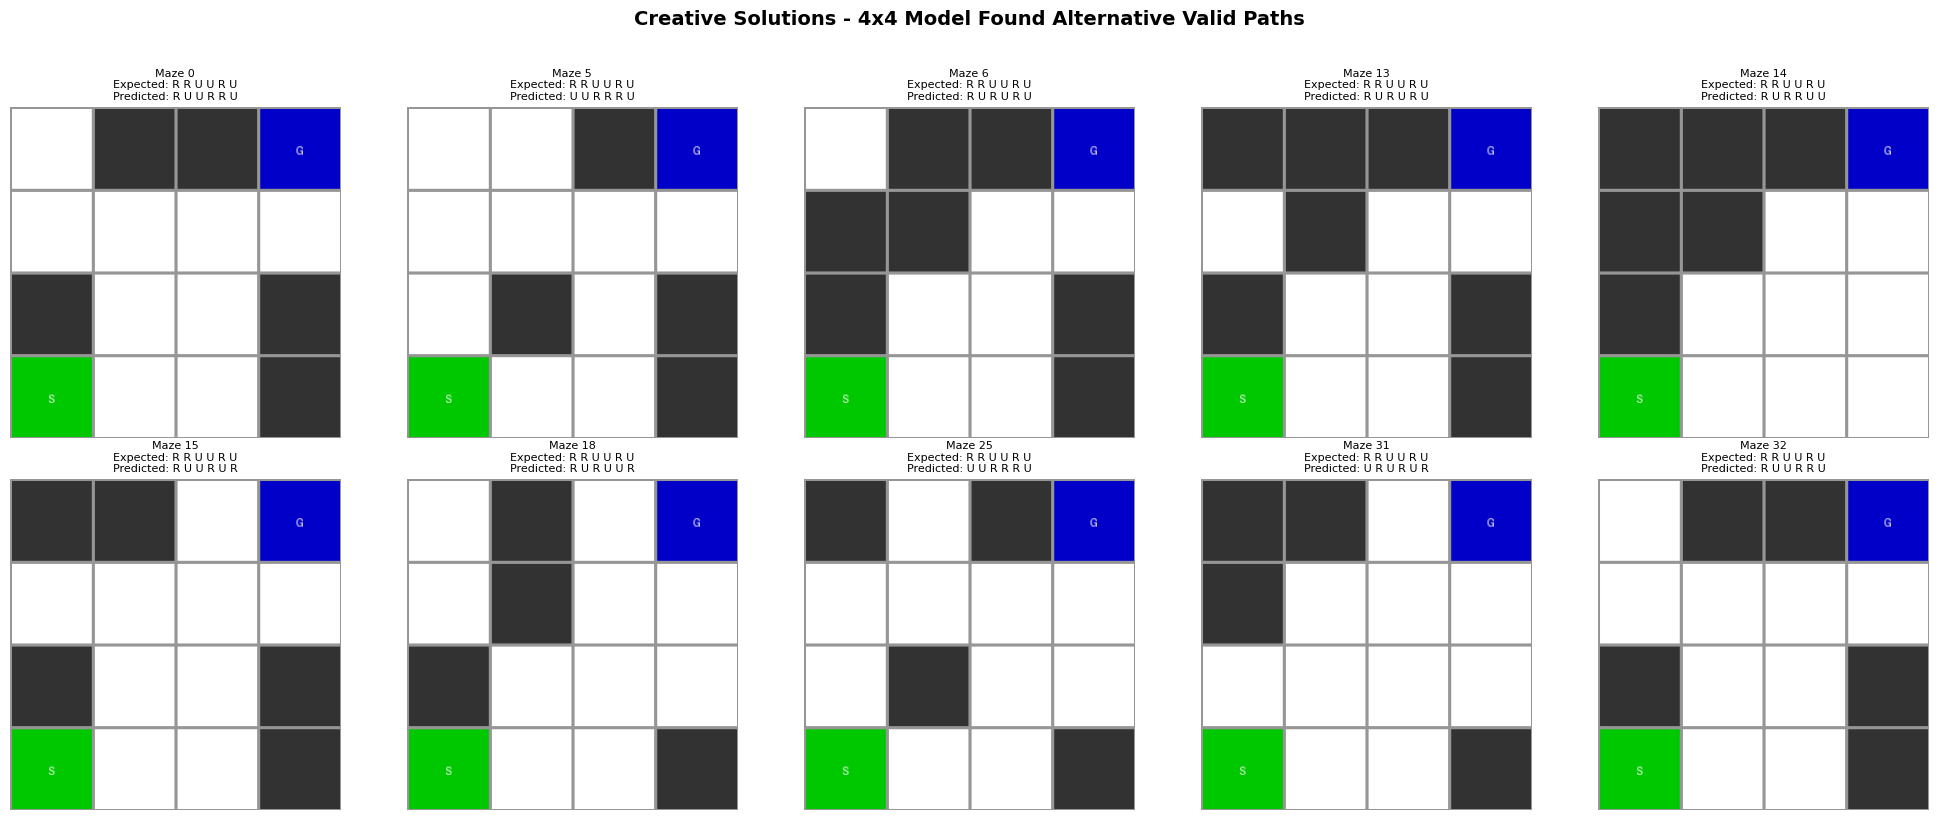

Results saved to results/4x4/

  ANALYZING 5x5
Generated 5x5 dataset

TEST SET INFO
Grid size:       5×5
Total entries:   1400
Variations:      100
Seed:            69
Start position:  (0, 4)
Goal position:   (4, 0)

Loaded 1400 maze grids
Model loaded: 12,215,488 params

5X5 TEST SET RESULTS - DETAILED ANALYSIS
Total mazes evaluated: 1400

Exact Match Accuracy:   248/1400 (17.7%)
Valid Solution Rate:    1157/1400 (82.6%)
Invalid Solutions:      243/1400 (17.4%)

Creative Solutions:     909/1400 (64.9%)
  ↳ Valid paths that differ from training solution

Sample Results:
----------------------------------------------------------------------

Maze 0: ✓ VALID
  Expected:  R U U U R U R R
  Predicted: R U R U U U R R

Maze 1: ✗ INVALID
  Expected:  R U U U R U R R
  Predicted: R U U R U U R R
  Failure: hit wall at position (1, 2)

Maze 2: ✓ VALID
  Expected:  R U U U R U R R
  Predicted: R U U U U R R R

Maze 3: ✓ VALID
  Expected:  R U U U R U R R
  Predicted: R U U R U U R R

Maze 4: ✓ 

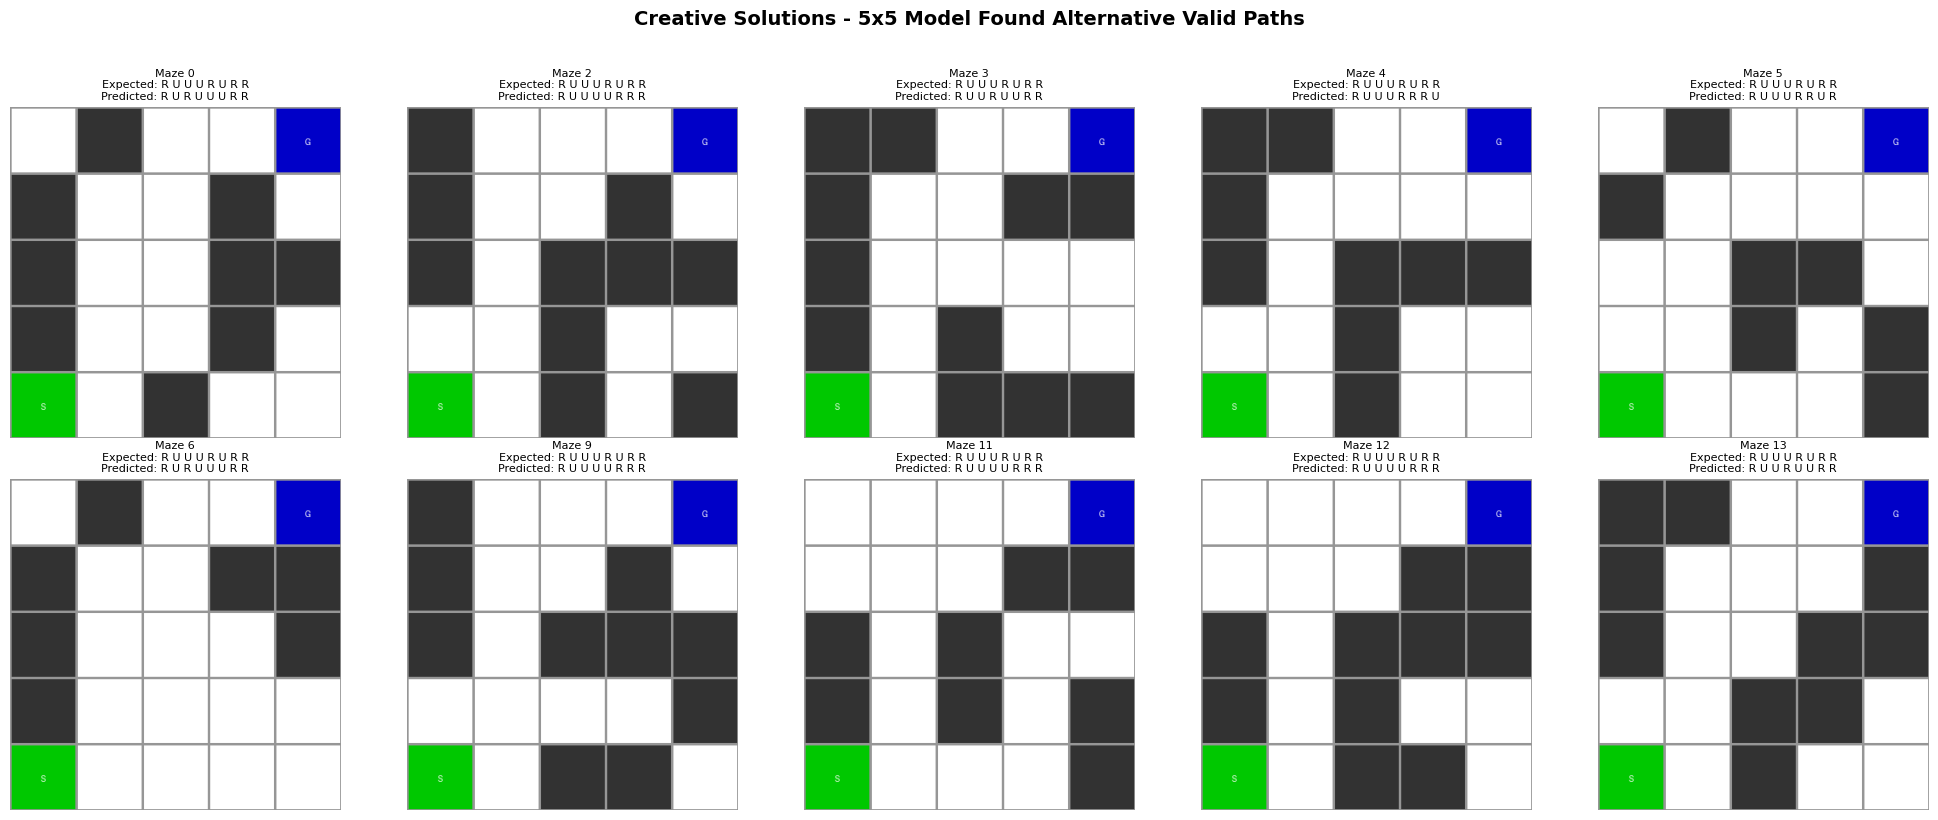

Results saved to results/5x5/


Completed analysis for 2 model(s)


In [18]:
all_results = []

for model_dir in model_dirs:
    grid_size = int(model_dir.split('x')[0])
    checkpoint_path = f'models/{model_dir}/resnet_gpt2_prefix.pth'

    if not os.path.exists(checkpoint_path):
        print(f"Skipping {model_dir} — no checkpoint found")
        continue

    result = analyze_one_model(grid_size, checkpoint_path)
    all_results.append(result)

print(f"\n\nCompleted analysis for {len(all_results)} model(s)")

## Comparison Table

In [19]:
# Print comparison table
print(f"\n{'='*80}")
print("CROSS-GRID COMPARISON")
print(f"{'='*80}")
print(f"{'Grid':<8} {'Loss':<10} {'Train Acc':<12} {'Exact Match':<14} {'Valid Soln':<14} {'Creative':<12}")
print(f"{'-'*80}")

for r in all_results:
    loss_str = f"{r['loss']:.4f}" if r['loss'] is not None else "N/A"
    train_str = f"{r['train_acc']:.1f}%" if r['train_acc'] is not None else "N/A"
    print(
        f"{r['grid_size']}x{r['grid_size']:<5} "
        f"{loss_str:<10} "
        f"{train_str:<12} "
        f"{r['exact_match_pct']:.1f}%{'':<9} "
        f"{r['valid_solution_pct']:.1f}%{'':<9} "
        f"{r['creative_pct']:.1f}%"
    )

print(f"{'='*80}")
print("\nKey insight: Valid Solution Rate is the true performance metric.")
print("Exact Match underestimates performance because multiple valid paths exist.")


CROSS-GRID COMPARISON
Grid     Loss       Train Acc    Exact Match    Valid Soln     Creative    
--------------------------------------------------------------------------------
4x4     0.1377     73.2%        5.7%          54.2%          48.5%
5x5     0.1139     74.8%        17.7%          82.6%          64.9%

Key insight: Valid Solution Rate is the true performance metric.
Exact Match underestimates performance because multiple valid paths exist.


## Comparison Chart

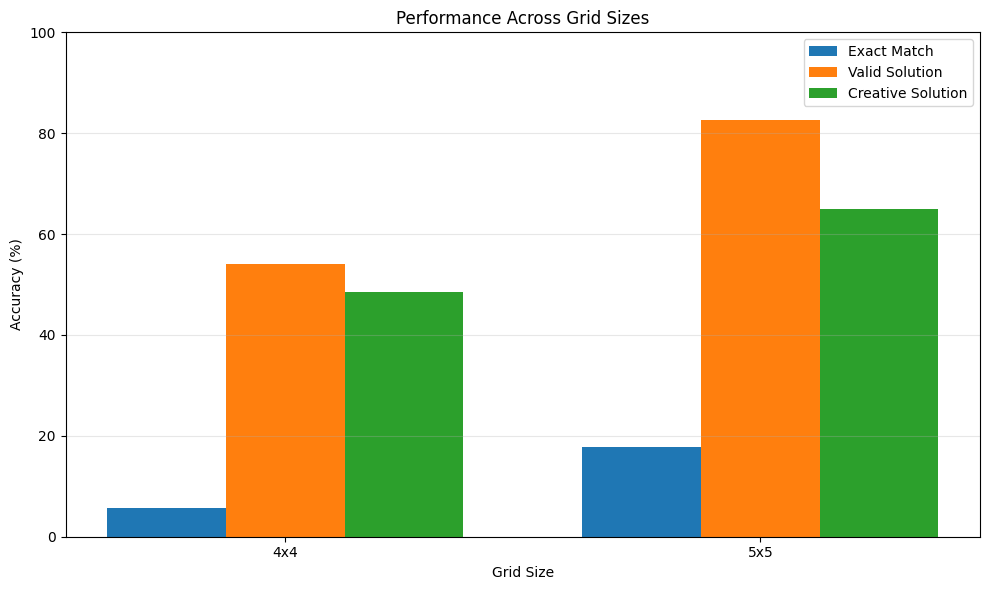

Saved to results/comparison.png


In [20]:
if len(all_results) > 1:
    labels = [f"{r['grid_size']}x{r['grid_size']}" for r in all_results]
    exact = [r['exact_match_pct'] for r in all_results]
    valid = [r['valid_solution_pct'] for r in all_results]
    creative = [r['creative_pct'] for r in all_results]

    x = np.arange(len(labels))
    width = 0.25

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(x - width, exact, width, label='Exact Match')
    ax.bar(x, valid, width, label='Valid Solution')
    ax.bar(x + width, creative, width, label='Creative Solution')

    ax.set_ylabel('Accuracy (%)')
    ax.set_xlabel('Grid Size')
    ax.set_title('Performance Across Grid Sizes')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.legend()
    ax.set_ylim(0, 100)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('results/comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved to results/comparison.png")
else:
    print("Only one model found — skipping comparison chart.")